# ESG vs Desempenho Financeiro — Notebook Organizado

**Objetivo:** analisar o impacto das métricas ESG no desempenho financeiro das empresas do S&P 500 (2019–2023), combinando modelos econométricos em painel e modelação preditiva com Random Forest.

Este notebook está organizado para acompanhar a lógica da dissertação:

1. Configuração inicial  
2. Importação dos dados  
3. Preparação, qualidade e winsorização  
4. Estatísticas descritivas, correlação e VIF  
5. Modelos econométricos principais  
6. Testes de robustez/modelos alternativos  
7. Diagnósticos econométricos  
8. Random Forest  
9. Exportação de tabelas para a tese

## 1. Configuração inicial

In [ ]:
# ==========================================================
# 1. CONFIGURAÇÃO INICIAL
# ==========================================================

# Bibliotecas base
from pathlib import Path
import sys
import platform
import warnings

import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt

# Estatística/econometria
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from scipy.stats import jarque_bera

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Painel: instalar automaticamente se necessário
try:
    from linearmodels.panel import PanelOLS, RandomEffects
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "linearmodels"])
    from linearmodels.panel import PanelOLS, RandomEffects

warnings.filterwarnings("ignore")
np.random.seed(42)

# Opções de visualização
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(f"Python: {sys.version.split()[0]} | OS: {platform.system()}")


Python: 3.12.13 | OS: Linux


## 2. Importação dos dados

> Nota: no teu ficheiro, apesar da extensão `.csv`, o conteúdo parece ser Excel. Por isso usamos `pd.read_excel()`.

In [ ]:
# ==========================================================
# 2. IMPORTAÇÃO DOS DADOS
# ==========================================================

# Ajusta este caminho se o ficheiro tiver outro nome/localização no Colab
DATA_PATH = Path("/content/Base_with_TobinQ_validated.csv.xlsx")

# Ler ficheiro exportado/validado
# O ficheiro tem extensão .csv, mas foi identificado como Excel; por isso usamos read_excel.
df_raw = pd.read_excel(DATA_PATH)

print("Shape inicial:", df_raw.shape)
print("Colunas:")
print(df_raw.columns.tolist())

df_raw.head()


Shape inicial: (2515, 18)
Colunas:
['Identifier', 'Company', 'Industry', 'Year', 'ESG', 'Social', 'Governance', 'Environmental', 'Controversies', 'ROA', 'ROE', 'Assets', 'Debt', 'Equity', 'lnAssets', 'Leverage', 'MarketCap', 'TobinQ']


,Identifier,Company,Industry,Year,ESG,Social,Governance,Environmental,Controversies,ROA,ROE,Assets,Debt,Equity,lnAssets,Leverage,MarketCap,TobinQ
0,A.N,Agilent Technologies Inc,Advanced Medical Equipment & Technology,2023,80.0128,93.4044,63.4774,77.6627,100.0000,0.1140,0.2195,11846000000.0000,3390000000.0000,5898000000.0000,23.1953,0.2862,38312829097.7400,3.5204
1,A.N,Agilent Technologies Inc,Advanced Medical Equipment & Technology,2022,81.9147,93.7739,67.3929,79.5726,100.0000,0.1165,0.2224,10763000000.0000,2735000000.0000,5845000000.0000,23.0994,0.2541,40736360301.0600,4.0390
2,A.N,Agilent Technologies Inc,Advanced Medical Equipment & Technology,2021,88.1410,91.3439,88.1340,79.1193,100.0000,0.1181,0.2345,10532000000.0000,2769000000.0000,5305000000.0000,23.0777,0.2629,44307180786.0000,4.4698
3,A.N,Agilent Technologies Inc,Advanced Medical Equipment & Technology,2020,86.9592,93.5081,81.8381,79.4558,100.0000,0.1190,0.2358,10705000000.0000,2729000000.0000,5389000000.0000,23.0940,0.2549,48214427241.0500,4.7588
4,A.N,Agilent Technologies Inc,Advanced Medical Equipment & Technology,2019,87.7744,93.9840,83.4634,79.4922,100.0000,0.0754,0.1495,9627000000.0000,2359000000.0000,4873000000.0000,22.9878,0.2450,36358600335.7400,4.0218


## 3. Preparação, qualidade dos dados e winsorização

In [ ]:
# ==========================================================
# 3.1 CÓPIA DE TRABALHO E DEFINIÇÃO DAS VARIÁVEIS
# ==========================================================

df = df_raw.copy()

# Variáveis do estudo
id_cols = ["Identifier", "Company", "Industry", "Year"]

dependent_vars = ["TobinQ", "ROA", "ROE"]
esg_vars = ["ESG", "Environmental", "Social", "Governance", "Controversies"]
control_vars = ["lnAssets", "Leverage"]
financial_base_vars = ["Assets", "Debt", "Equity", "MarketCap"]

main_vars = dependent_vars + esg_vars + control_vars

print("Variáveis dependentes:", dependent_vars)
print("Variáveis ESG:", esg_vars)
print("Variáveis de controlo:", control_vars)


Variáveis dependentes: ['TobinQ', 'ROA', 'ROE']
Variáveis ESG: ['ESG', 'Environmental', 'Social', 'Governance', 'Controversies']
Variáveis de controlo: ['lnAssets', 'Leverage']


In [ ]:
# ==========================================================
# 3.2 INSPEÇÃO INICIAL E CONVERSÃO DE TIPOS
# ==========================================================

print("Tipos de dados antes da conversão:")
print(df.dtypes)

# Garantir que o ano está como inteiro
if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")

# Converter variáveis numéricas para float
numeric_candidates = dependent_vars + esg_vars + control_vars + financial_base_vars

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Filtrar período de análise
if "Year" in df.columns:
    df = df[df["Year"].between(2019, 2023)].copy()

print("\nShape após conversão e filtro 2019–2023:", df.shape)

print("\nMissing values principais:")
print(df[main_vars].isna().sum().sort_values(ascending=False))

# Verificar duplicados empresa-ano
duplicates = df.duplicated(subset=["Identifier", "Year"]).sum()
print("Duplicados Identifier-Year:", duplicates)

Tipos de dados antes da conversão:
Identifier        object
Company           object
Industry          object
Year               int64
ESG              float64
Social           float64
Governance       float64
Environmental    float64
Controversies    float64
ROA              float64
ROE              float64
Assets           float64
Debt             float64
Equity           float64
lnAssets         float64
Leverage         float64
MarketCap        float64
TobinQ           float64
dtype: object

Shape após conversão e filtro 2019–2023: (2515, 18)

Missing values principais:
ROE              153
TobinQ            55
Governance        41
ESG               41
Environmental     41
Social            41
Controversies     41
ROA                9
lnAssets           4
Leverage           4
dtype: int64
Duplicados Identifier-Year: 0


In [ ]:
# ==========================================================
# 3.3 TRATAMENTO DE OUTLIERS — WINSORIZAÇÃO 1% / 99%
# ==========================================================

# A winsorização limita valores extremos aos percentis 1% e 99%.
# Isto reduz o impacto de outliers nas regressões, especialmente em variáveis financeiras como ROE.

def winsorize_series(series, lower=0.01, upper=0.99):
    """Winsoriza uma série numérica entre os percentis lower e upper."""
    lower_bound = series.quantile(lower)
    upper_bound = series.quantile(upper)
    return series.clip(lower=lower_bound, upper=upper_bound)

# Criar cópia winsorizada para manter o dataset original intacto
df_w = df.copy()

# Variáveis contínuas/financeiras a winsorizar
vars_to_winsorize = [
    "TobinQ",
    "ROA",
    "ROE",
    "lnAssets",
    "Leverage"
]

for var in vars_to_winsorize:
    if var in df_w.columns:
        df_w[var] = winsorize_series(df_w[var], lower=0.01, upper=0.99)

# Comparação rápida antes/depois para validar a winsorização
comparison = pd.DataFrame({
    "Antes_max": df[vars_to_winsorize].max(),
    "Depois_max": df_w[vars_to_winsorize].max(),
    "Antes_min": df[vars_to_winsorize].min(),
    "Depois_min": df_w[vars_to_winsorize].min(),
})
comparison


,Antes_max,Depois_max,Antes_min,Depois_min
TobinQ,29.5448,13.6230,0.0551,0.1433
ROA,0.8220,0.3167,-0.8561,-0.1677
ROE,288.0577,4.4949,-6.0149,-0.6056
lnAssets,29.0180,27.8076,20.1640,21.2833
Leverage,3.1345,1.0107,0.0000,0.0000


In [ ]:
# ==========================================================
# 3.4 PREPARAÇÃO DO DATASET EM PAINEL
# ==========================================================

# Dataset com índice de painel: empresa x ano
# Este será usado na maioria dos modelos econométricos.

df_panel = (
    df_w
    .dropna(subset=["Identifier", "Year"])
    .set_index(["Identifier", "Year"])
    .sort_index()
)

print("Índice do painel:", df_panel.index.names)
print("Shape do painel:", df_panel.shape)
print("N.º de empresas:", df_panel.index.get_level_values(0).nunique())
print("Anos:", sorted(df_panel.index.get_level_values(1).unique()))


Índice do painel: ['Identifier', 'Year']
Shape do painel: (2515, 16)
N.º de empresas: 503
Anos: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## 4. Estatísticas descritivas, correlação e VIF

In [ ]:
# ==========================================================
# 4.1 ESTATÍSTICAS DESCRITIVAS
# ==========================================================

vars_desc = [
    "TobinQ", "ROA", "ROE",
    "ESG", "Environmental", "Social", "Governance",
    "lnAssets", "Leverage"
]

# Tabela de estatísticas descritivas com dados winsorizados
desc_stats = df_w[vars_desc].describe().T
desc_stats["median"] = df_w[vars_desc].median()

desc_stats = desc_stats[["mean", "median", "std", "min", "max", "count"]]
desc_stats.columns = ["Média", "Mediana", "Desv_Padrão", "Mínimo", "Máximo", "N"]
desc_stats = desc_stats.round(4)

desc_stats.to_excel("Tabela_1_Estatisticas_Descritivas.xlsx")
desc_stats


,Média,Mediana,Desv_Padrão,Mínimo,Máximo,N
TobinQ,2.6009,1.7381,2.5200,0.1433,13.6230,2460.0000
ROA,0.0730,0.0578,0.0779,-0.1677,0.3167,2506.0000
ROE,0.2876,0.1620,0.5894,-0.6056,4.4949,2362.0000
ESG,58.6227,60.2786,15.3481,10.8315,92.3787,2474.0000
Environmental,60.3887,64.8112,21.9176,0.0000,97.8806,2474.0000
Social,68.4198,71.3314,16.7890,12.8833,97.6802,2474.0000
Governance,64.1150,66.9319,19.3867,1.0706,99.4670,2474.0000
lnAssets,24.0691,23.9654,1.3075,21.2833,27.8076,2511.0000
Leverage,0.2979,0.2811,0.1961,0.0000,1.0107,2511.0000


In [ ]:
# ==========================================================
# 4.2 MATRIZ DE CORRELAÇÃO DE PEARSON
# ==========================================================

vars_corr = vars_desc.copy()

corr_matrix = df_w[vars_corr].corr(method="pearson").round(3)

# Matriz triangular inferior para apresentação na tese
corr_matrix_lower = corr_matrix.where(np.tril(np.ones(corr_matrix.shape)).astype(bool))
corr_matrix_lower.to_excel("Tabela_2_Matriz_Correlacao.xlsx")

corr_matrix_lower


,TobinQ,ROA,ROE,ESG,Environmental,Social,Governance,lnAssets,Leverage
TobinQ,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ROA,0.5630,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ROE,0.2580,0.4420,1.0000,NaN,NaN,NaN,NaN,NaN,NaN
ESG,-0.1300,-0.0400,0.0500,1.0000,NaN,NaN,NaN,NaN,NaN
Environmental,-0.1910,-0.0780,0.0210,0.5330,1.0000,NaN,NaN,NaN,NaN
Social,-0.1150,-0.0430,0.0420,0.5310,0.6280,1.0000,NaN,NaN,NaN
Governance,-0.1630,-0.0270,0.0550,0.4750,0.2790,0.2030,1.0000,NaN,NaN
lnAssets,-0.4980,-0.3320,-0.1110,-0.0420,0.3420,0.2770,0.1350,1.0000,NaN
Leverage,0.0360,-0.0450,0.1550,0.1160,0.1720,0.1050,0.0340,-0.0600,1.0000


In [ ]:
# ==========================================================
# 4.3 P-VALUES DA MATRIZ DE CORRELAÇÃO
# ==========================================================

def corr_pvalues(data):
    """Calcula p-values para correlações de Pearson."""
    data = data.dropna()
    pvals = pd.DataFrame(np.ones((data.shape[1], data.shape[1])), columns=data.columns, index=data.columns)

    for i in data.columns:
        for j in data.columns:
            if i == j:
                pvals.loc[i, j] = 0.0
            else:
                _, pval = stats.pearsonr(data[i], data[j])
                pvals.loc[i, j] = pval
    return pvals

p_values_corr = corr_pvalues(df_w[vars_corr]).round(4)
p_values_corr.to_excel("Tabela_2_Pvalues_Correlacao.xlsx")
p_values_corr


,TobinQ,ROA,ROE,ESG,Environmental,Social,Governance,lnAssets,Leverage
TobinQ,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
ROA,0.0000,0.0000,0.0000,0.0339,0.0004,0.0127,0.0869,0.0000,0.0000
ROE,0.0000,0.0000,0.0000,0.0204,0.3766,0.0566,0.0111,0.0000,0.0000
ESG,0.0000,0.0339,0.0204,0.0000,0.0000,0.0000,0.0000,0.0272,0.0000
Environmental,0.0000,0.0004,0.3766,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Social,0.0000,0.0127,0.0566,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Governance,0.0000,0.0869,0.0111,0.0000,0.0000,0.0000,0.0000,0.0000,0.0038
lnAssets,0.0000,0.0000,0.0000,0.0272,0.0000,0.0000,0.0000,0.0000,0.1126
Leverage,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0038,0.1126,0.0000


In [ ]:
# ==========================================================
# 4.4 MULTICOLINEARIDADE — VARIANCE INFLATION FACTOR (VIF)
# ==========================================================

def calculate_vif(data, variables):
    """Calcula VIF para uma lista de variáveis explicativas."""
    X = data[variables].dropna().copy()
    X_const = sm.add_constant(X)

    vif = pd.DataFrame({
        "Variável": X_const.columns,
        "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    })

    # Remover constante, porque não é interpretada na tese
    vif = vif[vif["Variável"] != "const"].reset_index(drop=True)
    return vif.round(4)

vif_esg = calculate_vif(df_w, ["ESG", "lnAssets", "Leverage"])
vif_pillars = calculate_vif(df_w, ["Environmental", "Social", "Governance", "lnAssets", "Leverage"])

# Tabela comparativa para a tese
vif_table = pd.DataFrame({
    "Variável": ["ESG", "Environmental", "Social", "Governance", "lnAssets", "Leverage"],
    "Modelo ESG": [
        vif_esg.loc[vif_esg["Variável"] == "ESG", "VIF"].squeeze(),
        "—", "—", "—",
        vif_esg.loc[vif_esg["Variável"] == "lnAssets", "VIF"].squeeze(),
        vif_esg.loc[vif_esg["Variável"] == "Leverage", "VIF"].squeeze(),
    ],
    "Modelo Pilares": [
        "—",
        vif_pillars.loc[vif_pillars["Variável"] == "Environmental", "VIF"].squeeze(),
        vif_pillars.loc[vif_pillars["Variável"] == "Social", "VIF"].squeeze(),
        vif_pillars.loc[vif_pillars["Variável"] == "Governance", "VIF"].squeeze(),
        vif_pillars.loc[vif_pillars["Variável"] == "lnAssets", "VIF"].squeeze(),
        vif_pillars.loc[vif_pillars["Variável"] == "Leverage", "VIF"].squeeze(),
    ]
})

vif_table.to_excel("Tabela_3_VIF.xlsx", index=False)
vif_table


,Variável,Modelo ESG,Modelo Pilares
0,ESG,1.0149,—
1,Environmental,—,1.8502
2,Social,—,1.6657
3,Governance,—,1.0879
4,lnAssets,1.0050,1.1620
5,Leverage,1.0170,1.0484


## 5. Modelos econométricos principais

Modelos de painel com efeitos fixos de empresa e de ano, usando erros-padrão robustos clusterizados por empresa.

In [ ]:
# =========================================================
# 5.1 FUNÇÕES AUXILIARES PARA MODELOS EM PAINEL
# =========================================================

import statsmodels.api as sm
from linearmodels.panel import PanelOLS


def run_pooled_ols(data, y_var, x_vars, model_name="Pooled OLS"):
    """
    Estima um modelo OLS pooled como benchmark comparativo.
    """

    # Selecionar variáveis e remover missing values
    temp = data[[y_var] + x_vars].dropna().copy()

    # Variável dependente
    y = temp[y_var]

    # Variáveis explicativas com constante
    X = sm.add_constant(temp[x_vars])

    # Estimar OLS com erros robustos HC3
    result = sm.OLS(y, X).fit(cov_type="HC3")

    # Imprimir resultados
    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)
    print(result.summary())

    return result


def run_fe_model(data, y_var, x_vars, model_name="FE Model",
                 entity_effects=True, time_effects=True,
                 cluster_entity=True):
    """
    Estima um modelo de painel com efeitos fixos.
    """

    # Construir lista de efeitos fixos
    effects = []

    if entity_effects:
        effects.append("EntityEffects")

    if time_effects:
        effects.append("TimeEffects")

    # Construir fórmula do modelo
    formula = f"{y_var} ~ " + " + ".join(x_vars)

    if effects:
        formula += " + " + " + ".join(effects)

    # Estimar modelo
    model = PanelOLS.from_formula(formula, data=data)

    # Ajustar modelo com erros-padrão clusterizados por empresa
    if cluster_entity:
        result = model.fit(cov_type="clustered", cluster_entity=True)
    else:
        result = model.fit(cov_type="robust")

    # Imprimir resultados
    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)
    print(result.summary)

    return result


In [ ]:
# ==========================================================
# 5.2 OLS BENCHMARK — TOBIN'S Q
# ==========================================================

ols_tq_esg = run_pooled_ols(
    data=df_w,
    y_var="TobinQ",
    x_vars=["ESG", "lnAssets", "Leverage"],
    model_name="OLS Benchmark — TobinQ ~ ESG + Controlos"
)

ols_tq_pillars = run_pooled_ols(
    data=df_w,
    y_var="TobinQ",
    x_vars=["Environmental", "Social", "Governance", "lnAssets", "Leverage"],
    model_name="OLS Benchmark — TobinQ ~ Pilares ESG + Controlos"
)



OLS Benchmark — TobinQ ~ ESG + Controlos
                            OLS Regression Results                            
Dep. Variable:                 TobinQ   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     182.3
Date:                Sat, 13 Jun 2026   Prob (F-statistic):          1.12e-106
Time:                        15:11:51   Log-Likelihood:                -5331.4
No. Observations:                2448   AIC:                         1.067e+04
Df Residuals:                    2444   BIC:                         1.069e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const     

In [ ]:
# =========================================================
# 5.3 MODELOS FE PRINCIPAIS — TOBIN'S Q
# =========================================================

# Modelo (1): TobinQ ~ ESG + controlos
results_tq_esg = run_fe_model(
    data=df_panel,
    y_var="TobinQ",
    x_vars=["ESG", "lnAssets", "Leverage"],
    model_name="FE — TobinQ ~ ESG + Controlos"
)

# Modelo (2): TobinQ ~ Pilares ESG + controlos
results_tq_pillars = run_fe_model(
    data=df_panel,
    y_var="TobinQ",
    x_vars=["Environmental", "Social", "Governance", "lnAssets", "Leverage"],
    model_name="FE — TobinQ ~ Pilares ESG + Controlos"
)



FE — TobinQ ~ ESG + Controlos
                          PanelOLS Estimation Summary                           
Dep. Variable:                 TobinQ   R-squared:                        0.0680
Estimator:                   PanelOLS   R-squared (Between):             -84.303
No. Observations:                2448   R-squared (Within):               0.0745
Date:                Sat, Jun 13 2026   R-squared (Overall):             -80.787
Time:                        15:11:51   Log-likelihood                   -2772.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      47.371
Entities:                         492   P-value                           0.0000
Avg Obs:                       4.9756   Distribution:                  F(3,1949)
Min Obs:                       3.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             4.01

In [ ]:
# ==========================================================
# 5.4 MODELOS FE — ROA
# ==========================================================

results_roa_esg = run_fe_model(
    data=df_panel,
    y_var="ROA",
    x_vars=["ESG", "lnAssets", "Leverage"],
    model_name="FE — ROA ~ ESG + Controlos"
)

results_roa_pillars = run_fe_model(
    data=df_panel,
    y_var="ROA",
    x_vars=["Environmental", "Social", "Governance", "lnAssets", "Leverage"],
    model_name="FE — ROA ~ Pilares ESG + Controlos"
)



FE — ROA ~ ESG + Controlos
                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROA   R-squared:                        0.0539
Estimator:                   PanelOLS   R-squared (Between):             -59.596
No. Observations:                2474   R-squared (Within):               0.0406
Date:                Sat, Jun 13 2026   R-squared (Overall):             -50.203
Time:                        15:11:51   Log-likelihood                    4438.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      37.302
Entities:                         501   P-value                           0.0000
Avg Obs:                       4.9381   Distribution:                  F(3,1966)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             6.5198


In [ ]:
# ==========================================================
# 5.5 MODELOS FE — ROE
# ==========================================================

results_roe_esg = run_fe_model(
    data=df_panel,
    y_var="ROE",
    x_vars=["ESG", "lnAssets", "Leverage"],
    model_name="FE — ROE ~ ESG + Controlos"
)

results_roe_pillars = run_fe_model(
    data=df_panel,
    y_var="ROE",
    x_vars=["Environmental", "Social", "Governance", "lnAssets", "Leverage"],
    model_name="FE — ROE ~ Pilares ESG + Controlos"
)



FE — ROE ~ ESG + Controlos
                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROE   R-squared:                        0.0083
Estimator:                   PanelOLS   R-squared (Between):             -27.490
No. Observations:                2334   R-squared (Within):              -0.0009
Date:                Sat, Jun 13 2026   R-squared (Overall):             -31.783
Time:                        15:11:51   Log-likelihood                   -518.07
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.1089
Entities:                         486   P-value                           0.0016
Avg Obs:                       4.8025   Distribution:                  F(3,1841)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             0.7681


In [ ]:
# ==========================================================
# 5.6 TABELA DE REGRESSÕES PRINCIPAIS — FORMATO TESE
# ==========================================================

def significance_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""


def extract_regression_column(result, model_name):
    rows = {}

    for var in result.params.index:
        coef = result.params[var]
        se = result.std_errors[var]
        pval = result.pvalues[var]
        stars = significance_stars(pval)

        rows[var] = f"{coef:.4f}{stars} ({se:.4f})"

    rows["Observações"] = int(result.nobs)
    rows["R² within"] = round(result.rsquared_within, 4)
    rows["FE Empresa"] = "Sim"
    rows["FE Ano"] = "Sim"

    return pd.Series(rows, name=model_name)


# =========================================================
# MODELOS FE ADICIONAIS — ROA E ROE COM PILARES ESG
# =========================================================

results_roa_pillars = run_fe_model(
    data=df_panel,
    y_var="ROA",
    x_vars=["Environmental", "Social", "Governance", "lnAssets", "Leverage"],
    model_name="FE – ROA ~ Pilares ESG + Controlos"
)

results_roe_pillars = run_fe_model(
    data=df_panel,
    y_var="ROE",
    x_vars=["Environmental", "Social", "Governance", "lnAssets", "Leverage"],
    model_name="FE – ROE ~ Pilares ESG + Controlos"
)


# =========================================================
# TABELA 4 — MODELOS PRINCIPAIS EM PAINEL COM FE
# =========================================================

reg_table_main = pd.concat([
    extract_regression_column(results_tq_esg, "(1) TobinQ ESG"),
    extract_regression_column(results_tq_pillars, "(2) TobinQ Pilares"),
    extract_regression_column(results_roa_esg, "(3) ROA ESG"),
    extract_regression_column(results_roa_pillars, "(4) ROA Pilares"),
    extract_regression_column(results_roe_esg, "(5) ROE ESG"),
    extract_regression_column(results_roe_pillars, "(6) ROE Pilares")
], axis=1)

row_order_main = [
    "ESG", "Environmental", "Social", "Governance",
    "lnAssets", "Leverage",
    "Observações", "R² within", "FE Empresa", "FE Ano"
]

reg_table_main = reg_table_main.reindex(row_order_main).fillna("—")

reg_table_main.to_excel("Tabela_4_Regressoes_Principais_FE.xlsx")

reg_table_main



FE – ROA ~ Pilares ESG + Controlos
                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROA   R-squared:                        0.0545
Estimator:                   PanelOLS   R-squared (Between):             -56.538
No. Observations:                2474   R-squared (Within):               0.0403
Date:                Sat, Jun 13 2026   R-squared (Overall):             -47.627
Time:                        15:11:52   Log-likelihood                    4439.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      22.638
Entities:                         501   P-value                           0.0000
Avg Obs:                       4.9381   Distribution:                  F(5,1964)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):            

,(1) TobinQ ESG,(2) TobinQ Pilares,(3) ROA ESG,(4) ROA Pilares,(5) ROE ESG,(6) ROE Pilares
ESG,0.0006 (0.0023),—,-0.0001 (0.0002),—,0.0013 (0.0012),—
Environmental,—,-0.0061 (0.0050),—,-0.0002 (0.0002),—,0.0007 (0.0011)
Social,—,-0.0023 (0.0046),—,0.0001 (0.0003),—,-0.0004 (0.0015)
Governance,—,-0.0051* (0.0026),—,0.0000 (0.0001),—,0.0011 (0.0008)
lnAssets,-1.2410*** (0.3676),-1.2022*** (0.3698),-0.0253 (0.0170),-0.0246 (0.0172),-0.1469 (0.1027),-0.1470 (0.1050)
Leverage,0.0814 (0.7841),0.0974 (0.7872),-0.2278*** (0.0529),-0.2285*** (0.0528),0.1406 (0.3719),0.1384 (0.3703)
Observações,2448,2448,2474,2474,2334,2334
R² within,0.0745,0.0829,0.0406,0.0403,-0.0009,0.0008
FE Empresa,Sim,Sim,Sim,Sim,Sim,Sim
FE Ano,Sim,Sim,Sim,Sim,Sim,Sim


## 6. Testes de robustez e modelos alternativos

In [ ]:
# ==========================================================
# 6.1 CRIAR VARIÁVEIS DEFASADAS (t-1)
# ==========================================================

# Trabalhar numa cópia do dataset winsorizado
# Ordenar por empresa e ano antes de criar lags é essencial.
df_lag = df_w.sort_values(["Identifier", "Year"]).copy()

# Criar lags por empresa
df_lag["ESG_lag"] = df_lag.groupby("Identifier")["ESG"].shift(1)
df_lag["Environmental_lag"] = df_lag.groupby("Identifier")["Environmental"].shift(1)
df_lag["Social_lag"] = df_lag.groupby("Identifier")["Social"].shift(1)
df_lag["Governance_lag"] = df_lag.groupby("Identifier")["Governance"].shift(1)

# Definir painel para modelos com lag
df_lag_panel = df_lag.set_index(["Identifier", "Year"]).sort_index()

print(df_lag[["ESG_lag", "Environmental_lag", "Social_lag", "Governance_lag"]].isna().sum())


ESG_lag              542
Environmental_lag    542
Social_lag           542
Governance_lag       542
dtype: int64


In [ ]:
# ==========================================================
# 6.2 ROBUSTEZ — MODELOS COM VARIÁVEIS DEFASADAS
# ==========================================================

results_tq_esg_lag = run_fe_model(
    data=df_lag_panel,
    y_var="TobinQ",
    x_vars=["ESG_lag", "lnAssets", "Leverage"],
    model_name="Robustez — TobinQ ~ ESG(t-1) + Controlos"
)

results_tq_pillars_lag = run_fe_model(
    data=df_lag_panel,
    y_var="TobinQ",
    x_vars=["Environmental_lag", "Social_lag", "Governance_lag", "lnAssets", "Leverage"],
    model_name="Robustez — TobinQ ~ Pilares ESG(t-1) + Controlos"
)

# ROA - ESG lag
results_roa_esg_lag = run_fe_model(
    data=df_lag_panel,
    y_var="ROA",
    x_vars=["ESG_lag", "lnAssets", "Leverage"],
    model_name="Robustez - ROA ~ ESG(t-1) + Controlos"
)

# ROA - Pilares lag
results_roa_pillars_lag = run_fe_model(
    data=df_lag_panel,
    y_var="ROA",
    x_vars=["Environmental_lag", "Social_lag", "Governance_lag", "lnAssets", "Leverage"],
    model_name="Robustez - ROA ~ Pilares ESG(t-1) + Controlos"
)

# ROE - ESG lag
results_roe_esg_lag = run_fe_model(
    data=df_lag_panel,
    y_var="ROE",
    x_vars=["ESG_lag", "lnAssets", "Leverage"],
    model_name="Robustez - ROE ~ ESG(t-1) + Controlos"
)

# ROE - Pilares lag
results_roe_pillars_lag = run_fe_model(
    data=df_lag_panel,
    y_var="ROE",
    x_vars=["Environmental_lag", "Social_lag", "Governance_lag", "lnAssets", "Leverage"],
    model_name="Robustez - ROE ~ Pilares ESG(t-1) + Controlos"
)


Robustez — TobinQ ~ ESG(t-1) + Controlos
                          PanelOLS Estimation Summary                           
Dep. Variable:                 TobinQ   R-squared:                        0.0340
Estimator:                   PanelOLS   R-squared (Between):             -54.368
No. Observations:                1956   R-squared (Within):               0.0419
Date:                Sat, Jun 13 2026   R-squared (Overall):             -52.512
Time:                        15:11:52   Log-likelihood                   -2053.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      17.117
Entities:                         492   P-value                           0.0000
Avg Obs:                       3.9756   Distribution:                  F(3,1458)
Min Obs:                       2.0000                                           
Max Obs:                       4.0000   F-statistic (robust):      

In [ ]:
# ==========================================================
# 6.3 ROBUSTEZ — PAINEL EQUILIBRADO
# ==========================================================

# Selecionar empresas com observações nos 5 anos de análise
counts_years = df_w[["Identifier", "Year"]].drop_duplicates().groupby("Identifier")["Year"].nunique()
balanced_ids = counts_years[counts_years == 5].index

# Criar painel equilibrado
df_bal = df_w[df_w["Identifier"].isin(balanced_ids)].copy()
df_bal_panel = df_bal.set_index(["Identifier", "Year"]).sort_index()

print("Empresas no painel equilibrado:", len(balanced_ids))
print("Shape painel equilibrado:", df_bal.shape)

results_bal_tq_esg = run_fe_model(
    data=df_bal_panel,
    y_var="TobinQ",
    x_vars=["ESG", "lnAssets", "Leverage"],
    model_name="Robustez — Painel equilibrado — TobinQ ~ ESG + Controlos"
)

results_bal_tq_pillars = run_fe_model(
    data=df_bal_panel,
    y_var="TobinQ",
    x_vars=["Environmental", "Social", "Governance", "lnAssets", "Leverage"],
    model_name="Robustez — Painel equilibrado — TobinQ ~ Pilares ESG + Controlos"
)


Empresas no painel equilibrado: 503
Shape painel equilibrado: (2515, 18)

Robustez — Painel equilibrado — TobinQ ~ ESG + Controlos
                          PanelOLS Estimation Summary                           
Dep. Variable:                 TobinQ   R-squared:                        0.0680
Estimator:                   PanelOLS   R-squared (Between):             -84.303
No. Observations:                2448   R-squared (Within):               0.0745
Date:                Sat, Jun 13 2026   R-squared (Overall):             -80.787
Time:                        15:11:54   Log-likelihood                   -2772.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      47.371
Entities:                         492   P-value                           0.0000
Avg Obs:                       4.9756   Distribution:                  F(3,1949)
Min Obs:                       3.0000                      

In [ ]:
# ==========================================================
# 6.4 ROBUSTEZ — PILARES ESG ISOLADOS
# ==========================================================

# Estes modelos respondem ao possível problema de correlação entre pilares ESG.
# Cada pilar é introduzido individualmente no modelo.

results_tq_env_only = run_fe_model(
    data=df_panel,
    y_var="TobinQ",
    x_vars=["Environmental", "lnAssets", "Leverage"],
    model_name="Robustez — TobinQ ~ Environmental + Controlos"
)

results_tq_soc_only = run_fe_model(
    data=df_panel,
    y_var="TobinQ",
    x_vars=["Social", "lnAssets", "Leverage"],
    model_name="Robustez — TobinQ ~ Social + Controlos"
)

results_tq_gov_only = run_fe_model(
    data=df_panel,
    y_var="TobinQ",
    x_vars=["Governance", "lnAssets", "Leverage"],
    model_name="Robustez — TobinQ ~ Governance + Controlos"
)



Robustez — TobinQ ~ Environmental + Controlos
                          PanelOLS Estimation Summary                           
Dep. Variable:                 TobinQ   R-squared:                        0.0716
Estimator:                   PanelOLS   R-squared (Between):             -81.508
No. Observations:                2448   R-squared (Within):               0.0791
Date:                Sat, Jun 13 2026   R-squared (Overall):             -78.109
Time:                        15:11:54   Log-likelihood                   -2767.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      50.105
Entities:                         492   P-value                           0.0000
Avg Obs:                       4.9756   Distribution:                  F(3,1949)
Min Obs:                       3.0000                                           
Max Obs:                       5.0000   F-statistic (robust): 

In [ ]:
# ==========================================================
# 6.5 TABELA DE MODELOS ALTERNATIVOS / ROBUSTEZ
# ==========================================================

reg_table_robust = pd.concat([
    extract_regression_column(results_tq_esg_lag, "(1) TobinQ ESG Lag"),
    extract_regression_column(results_tq_pillars_lag, "(2) TobinQ Pilares Lag"),
    extract_regression_column(results_roa_esg_lag, "(3) ROA ESG Lag"),
    extract_regression_column(results_roa_pillars_lag, "(4) ROA Pilares Lag"),
    extract_regression_column(results_roe_esg_lag, "(5) ROE ESG Lag"),
    extract_regression_column(results_roe_pillars_lag, "(6) ROE Pilares Lag"),
    extract_regression_column(results_tq_env_only, "(7) TobinQ Environmental"),
    extract_regression_column(results_tq_soc_only, "(8) TobinQ Social"),
    extract_regression_column(results_tq_gov_only, "(9) TobinQ Governance"),
], axis=1)

row_order_robust = [
    "ESG_lag", "Environmental_lag", "Social_lag", "Governance_lag",
    "Environmental", "Social", "Governance",
    "lnAssets", "Leverage",
    "Observações", "R² within", "FE Empresa", "FE Ano"
]

reg_table_robust = reg_table_robust.reindex(row_order_robust).fillna("—")
reg_table_robust.to_excel("Tabela_Robustez_Completa.xlsx")
reg_table_robust

,(1) TobinQ ESG Lag,(2) TobinQ Pilares Lag,(3) ROA ESG Lag,(4) ROA Pilares Lag,(5) ROE ESG Lag,(6) ROE Pilares Lag,(7) TobinQ Environmental,(8) TobinQ Social,(9) TobinQ Governance
ESG_lag,-0.0002 (0.0029),—,0.0001 (0.0002),—,-0.0009 (0.0013),—,—,—,—
Environmental_lag,—,-0.0062 (0.0051),—,-0.0001 (0.0003),—,-0.0004 (0.0013),—,—,—
Social_lag,—,0.0047 (0.0048),—,-0.0001 (0.0003),—,0.0021 (0.0017),—,—,—
Governance_lag,—,-0.0031 (0.0028),—,0.0001 (0.0001),—,0.0007 (0.0010),—,—,—
Environmental,—,—,—,—,—,—,-0.0073 (0.0051),—,—
Social,—,—,—,—,—,—,—,-0.0055 (0.0050),—
Governance,—,—,—,—,—,—,—,—,-0.0056** (0.0027)
lnAssets,-0.9565** (0.4391),-0.9491** (0.4459),-0.0251 (0.0197),-0.0243 (0.0204),-0.1462* (0.0881),-0.1445 (0.0916),-1.1987*** (0.3702),-1.2298*** (0.3704),-1.2401*** (0.3655)
Leverage,-0.0880 (0.9126),-0.1087 (0.9161),-0.1746*** (0.0519),-0.1736*** (0.0518),0.3933 (0.4454),0.4032 (0.4453),0.0724 (0.7829),0.0835 (0.7843),0.1072 (0.7880)
Observações,1956,1956,1973,1973,1853,1853,2448,2448,2448


## 7. Diagnósticos econométricos

Estes testes ajudam a justificar a escolha dos modelos e as correções aplicadas, como erros-padrão robustos clusterizados por empresa.

In [ ]:
# ==========================================================
# 7.1 TESTE DE HAUSMAN — FE vs RE (aproximação prática)
# ==========================================================

# Nota: linearmodels não tem uma função Hausman universal em todas as versões.
# Esta implementação compara coeficientes comuns entre FE e RE.

def hausman(fe_result, re_result):
    """Teste de Hausman para comparar FE e RE."""
    common_coef = fe_result.params.index.intersection(re_result.params.index)
    b_fe = fe_result.params[common_coef]
    b_re = re_result.params[common_coef]

    v_fe = fe_result.cov.loc[common_coef, common_coef]
    v_re = re_result.cov.loc[common_coef, common_coef]

    diff = b_fe - b_re
    cov_diff = v_fe - v_re

    stat = float(diff.T @ np.linalg.pinv(cov_diff) @ diff)
    df_h = len(common_coef)
    pval = 1 - stats.chi2.cdf(stat, df_h)

    return {"stat": stat, "df": df_h, "p_value": pval}

# Modelo RE comparável ao principal ESG (com constante via from_formula)
re_model_esg = RandomEffects.from_formula(
    "TobinQ ~ 1 + ESG + lnAssets + Leverage",
    data=df_panel
)
re_result_esg = re_model_esg.fit()

# Aplicar o teste de Hausman
hausman_esg = hausman(results_tq_esg, re_result_esg)
print(f"Hausman: chi2 = {hausman_esg['stat']:.4f}, "
      f"df = {hausman_esg['df']}, "
      f"p-value = {hausman_esg['p_value']:.4f}")
hausman_esg

Hausman: chi2 = 33.6173, df = 3, p-value = 0.0000


{'stat': 33.61727382826474,
 'df': 3,
 'p_value': np.float64(2.386213314720109e-07)}

In [ ]:
# ==========================================================
# 7.2 HETEROSCEDASTICIDADE — BREUSCH-PAGAN SOBRE RESÍDUOS DO FE
# ==========================================================

# O teste é aplicado sobre os resíduos do modelo FE principal (TobinQ ~ ESG + Controlos)
# em vez de sobre uma regressão OLS auxiliar, garantindo que diagnostica o modelo
# efectivamente reportado na tese.

# Resíduos do modelo FE principal
resid_fe = results_tq_esg.resids

# Regressores correspondentes (alinhados pelo índice do painel)
exog_fe = df_panel.loc[resid_fe.index, ["ESG", "lnAssets", "Leverage"]]
exog_fe = sm.add_constant(exog_fe)

# Aplicar Breusch-Pagan sobre os resíduos do FE
bp_test = het_breuschpagan(resid_fe, exog_fe)

bp_results = pd.Series({
    "LM statistic": bp_test[0],
    "LM p-value": bp_test[1],
    "F statistic": bp_test[2],
    "F p-value": bp_test[3]
})

print(f"Breusch-Pagan (sobre resíduos do FE):")
print(f"  LM = {bp_test[0]:.4f}, p-value = {bp_test[1]:.4f}")

bp_results


Breusch-Pagan (sobre resíduos do FE):
  LM = 172.9652, p-value = 0.0000


,0
LM statistic,172.9652
LM p-value,0.0000
F statistic,61.9371
F p-value,0.0000


In [ ]:
# ==========================================================
# 7.3 AUTOCORRELAÇÃO — TESTE TIPO WOOLDRIDGE (APROXIMAÇÃO)
# ==========================================================

# Estratégia prática:
# 1) obter resíduos do modelo FE principal
# 2) criar lag dos resíduos por empresa
# 3) regressar resíduo atual no resíduo defasado
# Se o coeficiente do resíduo defasado for significativo, há evidência de autocorrelação.

resid_df = results_tq_esg.resids.to_frame(name="resid")
resid_df = resid_df.sort_index()
resid_df["resid_lag"] = resid_df.groupby(level=0)["resid"].shift(1)
wool_data = resid_df.dropna()

wool_model = sm.OLS(wool_data["resid"], sm.add_constant(wool_data["resid_lag"])).fit()
print(wool_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  resid   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     24.20
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           9.42e-07
Time:                        15:11:55   Log-Likelihood:                -2134.8
No. Observations:                1956   AIC:                             4274.
Df Residuals:                    1954   BIC:                             4285.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0044      0.016     -0.271      0.7

In [ ]:
# ==========================================================
# 7.4 NORMALIDADE DOS RESÍDUOS — JARQUE-BERA
# ==========================================================

jb_stat, jb_pvalue = jarque_bera(results_tq_esg.resids.dropna())

jb_results = pd.Series({
    "Jarque-Bera statistic": jb_stat,
    "p-value": jb_pvalue
})

jb_results


,0
Jarque-Bera statistic,18570.1495
p-value,0.0000


In [ ]:
# ==========================================================
# 7.5 TABELA DE DIAGNÓSTICOS ECONOMÉTRICOS
# ==========================================================

diagnostics_table = pd.DataFrame({
    "Teste": [
    "Hausman (FE vs RE)",
    "Breusch-Pagan (resíduos FE)",
    "Autocorrelação tipo Wooldridge (aproximação)",
    "Jarque-Bera"
],
    "Estatística": [
        round(hausman_esg["stat"], 4),
        round(bp_results["LM statistic"], 4),
        round(wool_model.tvalues.get("resid_lag", np.nan), 4),
        round(jb_results["Jarque-Bera statistic"], 4)
    ],
    "p-value": [
        round(hausman_esg["p_value"], 4),
        round(bp_results["LM p-value"], 4),
        round(wool_model.pvalues.get("resid_lag", np.nan), 4),
        round(jb_results["p-value"], 4)
    ]
})

diagnostics_table.to_excel("Tabela_6_Diagnosticos_Econometricos.xlsx", index=False)
diagnostics_table


,Teste,Estatística,p-value
0,Hausman (FE vs RE),33.6173,0.0000
1,Breusch-Pagan (resíduos FE),172.9652,0.0000
2,Autocorrelação tipo Wooldridge (aproximação),4.9191,0.0000
3,Jarque-Bera,18570.1495,0.0000


In [ ]:
# ==========================================================
# 7.6 VARIAÇÃO INTRA-EMPRESA DOS SCORES ESG
# ==========================================================

# Análise da variação within (intra-empresa) das métricas ESG.
# Esta tabela sustenta empiricamente o argumento de que a limitação
# do poder estatístico dos modelos com efeitos fixos pode dever-se,
# em parte, à baixa variabilidade dos scores ESG ao longo do tempo
# para a mesma empresa.

# Calcular o desvio-padrão within (por empresa) para cada métrica ESG
within_var = pd.DataFrame({
    "ESG":           df_w.groupby("Identifier")["ESG"].std(),
    "Environmental": df_w.groupby("Identifier")["Environmental"].std(),
    "Social":        df_w.groupby("Identifier")["Social"].std(),
    "Governance":    df_w.groupby("Identifier")["Governance"].std(),
})

# Sumário descritivo da distribuição dos desvios-padrão within
within_summary = within_var.describe().round(3)
within_summary.columns = ["ESG", "Environmental", "Social", "Governance"]

# Para comparação, calcular também o desvio-padrão total (between+within)
overall_std = df_w[["ESG", "Environmental", "Social", "Governance"]].std().round(3)

# Construir tabela final consolidada
final_table = within_summary.copy()
final_table.loc["Std Total (referência)"] = overall_std

# Exportar para Excel
final_table.to_excel("Tabela_8_Variacao_Within_ESG.xlsx")

print("Distribuição do desvio-padrão WITHIN (intra-empresa) para cada métrica ESG:")
print("(comparado com o desvio-padrão TOTAL no fim como referência)")
print()
final_table

Distribuição do desvio-padrão WITHIN (intra-empresa) para cada métrica ESG:
(comparado com o desvio-padrão TOTAL no fim como referência)



,ESG,Environmental,Social,Governance
count,500.0000,500.0000,500.0000,500.0000
mean,8.0120,5.6900,4.9890,8.5870
std,4.9210,4.9980,3.4410,4.8450
min,0.5580,0.0000,0.3220,0.0000
25%,3.8280,2.4420,2.5560,5.1560
50%,6.6480,4.1510,4.1910,7.6110
75%,12.4960,7.4450,6.5970,11.0620
max,23.2600,27.9560,24.8290,27.5060
Std Total (referência),15.3480,21.9180,16.7890,19.3870


## 8. Random Forest — modelação preditiva

A modelação preditiva complementa a análise econométrica. O objetivo não é inferir causalidade, mas avaliar capacidade preditiva e importância relativa das variáveis.

In [ ]:
# ==========================================================
# 8.1 PREPARAÇÃO PARA RANDOM FOREST
# ==========================================================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Dois conjuntos de features distintos:
# - "agg" usa ESG agregado (modelo simples)
# - "pil" usa os 3 pilares E, S, G (modelo desagregado)
# Esta separação evita que o ESG agregado e os pilares partilhem variância
# explicada e distorçam a importância relativa.

features_agg = ["ESG", "Controversies", "lnAssets", "Leverage"]
features_pil = ["Environmental", "Social", "Governance",
                "Controversies", "lnAssets", "Leverage"]

targets_rf = ["TobinQ", "ROA", "ROE"]

# Variáveis derivadas para identificar conjuntos
feature_sets = {
    "Agg": features_agg,
    "Pil": features_pil
}

print("Targets:", targets_rf)
print("Features (Agg):", features_agg)
print("Features (Pil):", features_pil)

Targets: ['TobinQ', 'ROA', 'ROE']
Features (Agg): ['ESG', 'Controversies', 'lnAssets', 'Leverage']
Features (Pil): ['Environmental', 'Social', 'Governance', 'Controversies', 'lnAssets', 'Leverage']


In [ ]:
# ==========================================================
# 8.2 FUNÇÃO DE TUNING — GRID SEARCH CV
# ==========================================================

# Pequeno grid de hiperparâmetros, suficiente para legitimar
# a escolha sem tornar o tempo de execução proibitivo.

def tune_rf(X_train, y_train, verbose=True):
    """
    Tuning de hiperparâmetros via GridSearchCV (5-fold).
    Devolve o melhor estimador e os melhores parâmetros.
    """
    param_grid = {
        "n_estimators": [300, 500],
        "max_depth": [None, 15],
        "min_samples_leaf": [3, 7]
    }

    grid = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    if verbose:
        print(f"  Best params: {grid.best_params_}")
        print(f"  CV R² (best): {grid.best_score_:.4f}")

    return grid.best_estimator_, grid.best_params_

In [ ]:
# ==========================================================
# 8.3 FUNÇÃO PRINCIPAL — RANDOM FOREST COM TUNING + PERMUTATION
# ==========================================================

def run_rf_full(data, target, features, label="",
                test_size=0.2, random_state=42, tune=True):
    """
    Treina um Random Forest com tuning, calcula métricas out-of-sample
    e ambas as importâncias (MDI e Permutation).

    Parâmetros
    ----------
    data : DataFrame
    target : str — variável dependente
    features : list[str] — variáveis explicativas
    label : str — etiqueta para identificação
    test_size : float — fração para teste
    random_state : int — semente
    tune : bool — usar GridSearchCV (True) ou hiperparâmetros padrão (False)
    """
    temp = data[features + [target]].dropna()
    X = temp[features]
    y = temp[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print(f"\n>>> {label}")
    if tune:
        rf, best_params = tune_rf(X_train, y_train)
    else:
        rf = RandomForestRegressor(
            n_estimators=500, min_samples_leaf=5,
            random_state=random_state, n_jobs=-1
        )
        rf.fit(X_train, y_train)
        best_params = "default (n_est=500, min_leaf=5)"

    y_pred = rf.predict(X_test)

    # Baseline (média)
    dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
    y_dummy = dummy.predict(X_test)

    # Métricas
    metrics = {
        "Label": label,
        "Target": target,
        "Features": "Agg" if "ESG" in features and "Environmental" not in features else "Pil",
        "Split": "Random",
        "N_total": len(temp),
        "N_test": len(y_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2_oos": r2_score(y_test, y_pred),
        "Baseline_RMSE": np.sqrt(mean_squared_error(y_test, y_dummy)),
        "Baseline_R2": r2_score(y_test, y_dummy),
        "Best_params": str(best_params)
    }

    # Permutation importance (mais robusta que MDI)
    perm = permutation_importance(
        rf, X_test, y_test,
        n_repeats=30, random_state=random_state, n_jobs=-1
    )

    importances = pd.DataFrame({
        "Variável": features,
        "Importance_MDI": rf.feature_importances_,
        "Importance_Perm_Mean": perm.importances_mean,
        "Importance_Perm_Std": perm.importances_std
    }).sort_values("Importance_Perm_Mean", ascending=False)

    return rf, metrics, importances

In [ ]:
# ==========================================================
# 8.4 FUNÇÃO PARA TIME-BASED SPLIT (ROBUSTEZ TEMPORAL)
# ==========================================================

# Treina em 2019–2022, testa em 2023.
# Usa os melhores hiperparâmetros encontrados no random split,
# evitando re-tunar.

def run_rf_time_split(data, target, features, best_params,
                       train_years=(2019, 2020, 2021, 2022),
                       test_years=(2023,), label=""):
    """
    Random Forest com divisão temporal estrita.
    """
    temp = data.dropna(subset=features + [target] + ["Year"])
    train = temp[temp["Year"].isin(train_years)]
    test  = temp[temp["Year"].isin(test_years)]

    X_train, y_train = train[features], train[target]
    X_test,  y_test  = test[features],  test[target]

    # Filtrar best_params para argumentos que não sejam string
    if isinstance(best_params, dict):
        rf = RandomForestRegressor(
            random_state=42, n_jobs=-1, **best_params
        )
    else:
        rf = RandomForestRegressor(
            n_estimators=500, min_samples_leaf=5,
            random_state=42, n_jobs=-1
        )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
    y_dummy = dummy.predict(X_test)

    metrics = {
        "Label": label,
        "Target": target,
        "Features": "Agg" if "ESG" in features and "Environmental" not in features else "Pil",
        "Split": "TimeBased",
        "N_train": len(y_train),
        "N_test": len(y_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2_oos": r2_score(y_test, y_pred),
        "Baseline_R2": r2_score(y_test, y_dummy)
    }

    return rf, metrics

In [ ]:
# ==========================================================
# 8.5 EXECUTAR — RANDOM SPLIT COM TUNING
# ==========================================================

# Para cada combinação de target × conjunto de features,
# treinar um Random Forest tunado.

results_random = []
importances_dict = {}
best_params_dict = {}

for target in targets_rf:
    for set_name, feat_list in feature_sets.items():
        label = f"{target}_{set_name}"
        rf, m, imp = run_rf_full(df_w, target, feat_list, label=label)

        results_random.append(m)
        importances_dict[label] = imp
        best_params_dict[label] = eval(m["Best_params"]) if isinstance(m["Best_params"], str) else m["Best_params"]

rf_results_random = pd.DataFrame(results_random).round(4)
rf_results_random.to_excel("Tabela_7a_RF_RandomSplit.xlsx", index=False)
print("\n" + "=" * 60)
print("RANDOM SPLIT — Resultados consolidados")
print("=" * 60)
rf_results_random


>>> TobinQ_Agg
  Best params: {'max_depth': 15, 'min_samples_leaf': 3, 'n_estimators': 300}
  CV R² (best): 0.4770

>>> TobinQ_Pil
  Best params: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 500}
  CV R² (best): 0.5170

>>> ROA_Agg
  Best params: {'max_depth': 15, 'min_samples_leaf': 3, 'n_estimators': 500}
  CV R² (best): 0.2255

>>> ROA_Pil
  Best params: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 300}
  CV R² (best): 0.3028

>>> ROE_Agg
  Best params: {'max_depth': None, 'min_samples_leaf': 7, 'n_estimators': 500}
  CV R² (best): 0.0680

>>> ROE_Pil
  Best params: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 300}
  CV R² (best): 0.0970

RANDOM SPLIT — Resultados consolidados


,Label,Target,Features,Split,N_total,N_test,RMSE,MAE,R2_oos,Baseline_RMSE,Baseline_R2,Best_params
0,TobinQ_Agg,TobinQ,Agg,Random,2448,490,1.6657,1.1095,0.4945,2.3462,-0.0030,"{'max_depth': 15, 'min_samples_leaf': 3, 'n_es..."
1,TobinQ_Pil,TobinQ,Pil,Random,2448,490,1.5757,1.0351,0.5476,2.3462,-0.0030,"{'max_depth': None, 'min_samples_leaf': 3, 'n_..."
2,ROA_Agg,ROA,Agg,Random,2474,495,0.0600,0.0415,0.3203,0.0730,-0.0044,"{'max_depth': 15, 'min_samples_leaf': 3, 'n_es..."
3,ROA_Pil,ROA,Pil,Random,2474,495,0.0579,0.0397,0.3670,0.0730,-0.0044,"{'max_depth': None, 'min_samples_leaf': 3, 'n_..."
4,ROE_Agg,ROE,Agg,Random,2334,467,0.6108,0.2791,0.1668,0.6708,-0.0049,"{'max_depth': None, 'min_samples_leaf': 7, 'n_..."
5,ROE_Pil,ROE,Pil,Random,2334,467,0.5809,0.2654,0.2464,0.6708,-0.0049,"{'max_depth': None, 'min_samples_leaf': 3, 'n_..."


In [ ]:
# ==========================================================
# 8.6 EXECUTAR — TIME-BASED SPLIT (ROBUSTEZ)
# ==========================================================

# Reutilizar os melhores hiperparâmetros encontrados no random split

results_time = []

for target in targets_rf:
    for set_name, feat_list in feature_sets.items():
        label = f"{target}_{set_name}_Time"
        bp = best_params_dict.get(f"{target}_{set_name}", {})
        rf, m = run_rf_time_split(df_w, target, feat_list, bp, label=label)
        results_time.append(m)

rf_results_time = pd.DataFrame(results_time).round(4)
rf_results_time.to_excel("Tabela_7b_RF_TimeSplit.xlsx", index=False)
print("\n" + "=" * 60)
print("TIME-BASED SPLIT — Resultados (treino 2019-2022, teste 2023)")
print("=" * 60)
rf_results_time


TIME-BASED SPLIT — Resultados (treino 2019-2022, teste 2023)


,Label,Target,Features,Split,N_train,N_test,RMSE,MAE,R2_oos,Baseline_R2
0,TobinQ_Agg_Time,TobinQ,Agg,TimeBased,1956,492,1.8371,1.2366,0.4432,-0.0000
1,TobinQ_Pil_Time,TobinQ,Pil,TimeBased,1956,492,1.7637,1.1836,0.4868,-0.0000
2,ROA_Agg_Time,ROA,Agg,TimeBased,1973,501,0.0650,0.0461,0.1984,-0.0022
3,ROA_Pil_Time,ROA,Pil,TimeBased,1973,501,0.0608,0.0425,0.2987,-0.0022
4,ROE_Agg_Time,ROE,Agg,TimeBased,1863,471,0.4993,0.2422,0.1013,-0.0000
5,ROE_Pil_Time,ROE,Pil,TimeBased,1863,471,0.4648,0.2238,0.2213,-0.0000


In [ ]:
# ==========================================================
# 8.6b  R² INCREMENTAL DO ESG (A2)  +  RF vs OLS (A1)
# ==========================================================
# Responde a: "quanto é que o ESG ACRESCENTA à previsão, para além
# da dimensão (lnAssets) e do endividamento (Leverage)?"
#   - RF só controlos        -> R2_controlos
#   - RF controlos + ESG     -> R2_completo  (= modelo já reportado)
#   - DeltaR2 = completo - controlos  -> contributo REAL do ESG
#   - OLS (mesmas features)  -> linear vs não-linear (compara com o RF)
# MESMA amostra e MESMO split para todos, para isolar as features.

from sklearn.linear_model import LinearRegression

CONTROLOS = ["lnAssets", "Leverage"]
esg_blocks = {
    "Agg": ["ESG", "Controversies"],
    "Pil": ["Environmental", "Social", "Governance", "Controversies"],
}

def r2_incremental(data, target, set_name, random_state=42, test_size=0.2):
    esg  = esg_blocks[set_name]
    full = CONTROLOS + esg
    temp = data[full + [target]].dropna()              # mesma amostra p/ todos
    X, y = temp[full], temp[target]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    bp = best_params_dict.get(f"{target}_{set_name}", {})   # reutiliza tuning
    bp = bp if isinstance(bp, dict) else {}

    rf_c = RandomForestRegressor(random_state=random_state, n_jobs=-1, **bp)
    rf_c.fit(X_tr[CONTROLOS], y_tr)
    r2_c = r2_score(y_te, rf_c.predict(X_te[CONTROLOS]))    # RF só controlos

    rf_f = RandomForestRegressor(random_state=random_state, n_jobs=-1, **bp)
    rf_f.fit(X_tr[full], y_tr)
    r2_f = r2_score(y_te, rf_f.predict(X_te[full]))         # RF completo

    ols = LinearRegression().fit(X_tr[full], y_tr)
    r2_o = r2_score(y_te, ols.predict(X_te[full]))          # OLS mesmas features

    return {"Target": target, "Features": set_name, "N": len(temp),
            "R2_controlos_RF": r2_c, "R2_completo_RF": r2_f,
            "DeltaR2_ESG": r2_f - r2_c,
            "R2_completo_OLS": r2_o, "RF_menos_OLS": r2_f - r2_o}

rf_incremental = pd.DataFrame(
    [r2_incremental(df_w, t, s) for t in targets_rf for s in esg_blocks]
).round(4)
rf_incremental.to_excel("Tabela_8_R2_Incremental_ESG.xlsx", index=False)

print("="*64)
print("R² INCREMENTAL DO ESG (A2) + RF vs OLS (A1)")
print("="*64)
print(rf_incremental.to_string(index=False))
rf_incremental

R² INCREMENTAL DO ESG (A2) + RF vs OLS (A1)
Target Features    N  R2_controlos_RF  R2_completo_RF  DeltaR2_ESG  R2_completo_OLS  RF_menos_OLS
TobinQ      Agg 2448           0.4493          0.4947       0.0454           0.2776        0.2171
TobinQ      Pil 2448           0.4437          0.5473       0.1035           0.2806        0.2667
   ROA      Agg 2474           0.2398          0.3200       0.0802           0.1164        0.2036
   ROA      Pil 2474           0.2216          0.3665       0.1449           0.1145        0.2520
   ROE      Agg 2334           0.1358          0.1668       0.0309           0.0672        0.0996
   ROE      Pil 2334           0.0917          0.2456       0.1538           0.0698        0.1758


,Target,Features,N,R2_controlos_RF,R2_completo_RF,DeltaR2_ESG,R2_completo_OLS,RF_menos_OLS
0,TobinQ,Agg,2448,0.4493,0.4947,0.0454,0.2776,0.2171
1,TobinQ,Pil,2448,0.4437,0.5473,0.1035,0.2806,0.2667
2,ROA,Agg,2474,0.2398,0.3200,0.0802,0.1164,0.2036
3,ROA,Pil,2474,0.2216,0.3665,0.1449,0.1145,0.2520
4,ROE,Agg,2334,0.1358,0.1668,0.0309,0.0672,0.0996
5,ROE,Pil,2334,0.0917,0.2456,0.1538,0.0698,0.1758



Tabela consolidada (random + time-based):


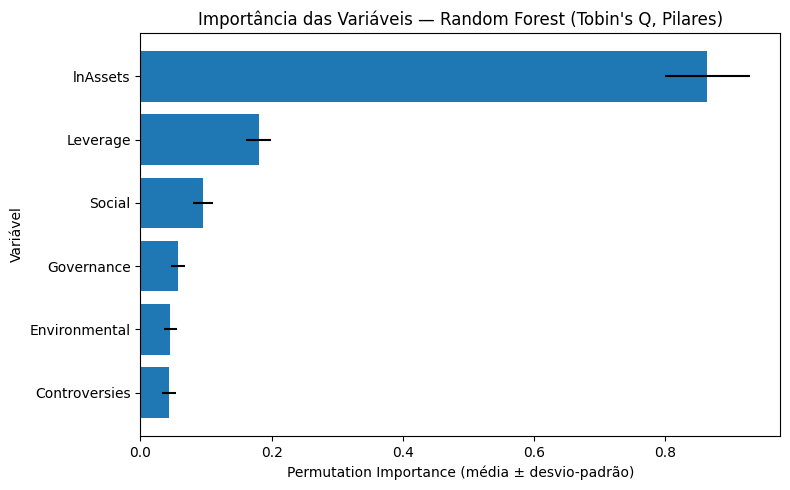

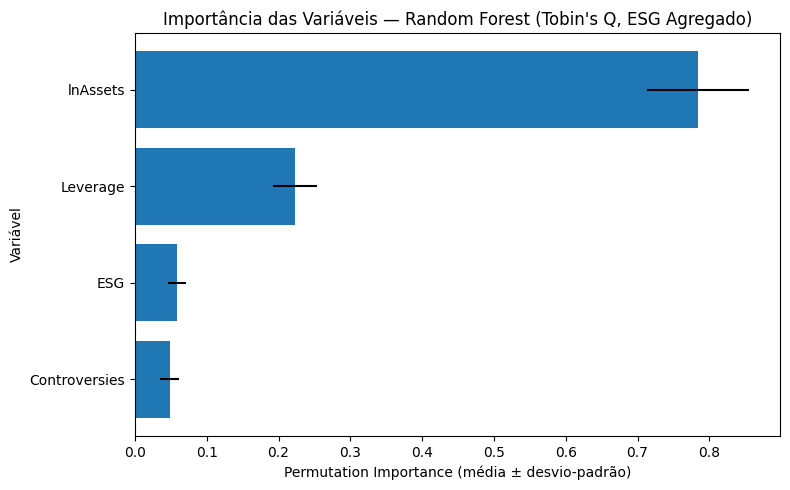

In [ ]:
# ==========================================================
# 8.7 TABELA CONSOLIDADA E FIGURAS DE FEATURE IMPORTANCE
# ==========================================================

# Tabela combinada (random + time-based) para comparação directa
common_cols = ["Label", "Target", "Features", "Split",
               "N_test", "RMSE", "MAE", "R2_oos", "Baseline_R2"]

rf_combined = pd.concat([
    rf_results_random[common_cols] if all(c in rf_results_random.columns for c in common_cols)
    else rf_results_random.reindex(columns=common_cols),
    rf_results_time[common_cols] if all(c in rf_results_time.columns for c in common_cols)
    else rf_results_time.reindex(columns=common_cols),
], ignore_index=True)

rf_combined.to_excel("Tabela_7_Random_Forest_Consolidado.xlsx", index=False)
print("\nTabela consolidada (random + time-based):")
rf_combined

# Exportar importâncias por modelo (Agg e Pil)
for label, imp in importances_dict.items():
    fname = f"Importancias_RF_{label}.xlsx"
    imp.to_excel(fname, index=False)

# Figura — Permutation Importance para TobinQ (Pilares)
imp_tq_pil = importances_dict["TobinQ_Pil"].copy()

plt.figure(figsize=(8, 5))
plt.barh(
    imp_tq_pil["Variável"],
    imp_tq_pil["Importance_Perm_Mean"],
    xerr=imp_tq_pil["Importance_Perm_Std"]
)
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (média ± desvio-padrão)")
plt.ylabel("Variável")
plt.title("Importância das Variáveis — Random Forest (Tobin's Q, Pilares)")
plt.tight_layout()
plt.savefig("Figura_1_Permutation_Importance_TobinQ.png", dpi=300)
plt.show()

# Figura — Permutation Importance para TobinQ (Agregado)
imp_tq_agg = importances_dict["TobinQ_Agg"].copy()

plt.figure(figsize=(8, 5))
plt.barh(
    imp_tq_agg["Variável"],
    imp_tq_agg["Importance_Perm_Mean"],
    xerr=imp_tq_agg["Importance_Perm_Std"]
)
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (média ± desvio-padrão)")
plt.ylabel("Variável")
plt.title("Importância das Variáveis — Random Forest (Tobin's Q, ESG Agregado)")
plt.tight_layout()
plt.savefig("Figura_2_Permutation_Importance_TobinQ_Agg.png", dpi=300)
plt.show()

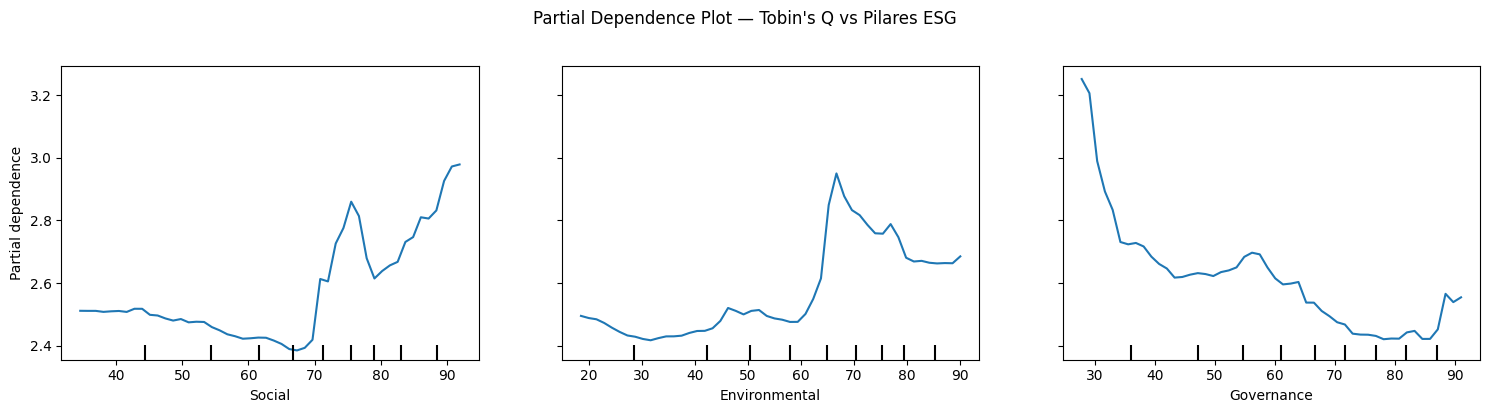

In [ ]:
# ==========================================================
# 8.8 PARTIAL DEPENDENCE PLOTS — Tobin's Q vs Pilares ESG
# ==========================================================

from sklearn.inspection import PartialDependenceDisplay

# Modelo Pil já treinado: rf_models.get("TobinQ_Pil") OU re-treinar
# Re-treinar para garantir consistência

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features_pil = ["Environmental","Social","Governance","Controversies","lnAssets","Leverage"]
temp = df_w[features_pil + ["TobinQ"]].dropna()
X = temp[features_pil]
y = temp["TobinQ"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_tq = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
rf_tq.fit(X_train, y_train)

# PDP — Social, Environmental, Governance
fig, ax = plt.subplots(figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    rf_tq, X_train, features=["Social", "Environmental", "Governance"],
    grid_resolution=50, ax=ax
)
plt.suptitle("Partial Dependence Plot — Tobin's Q vs Pilares ESG", y=1.02)
plt.tight_layout()
plt.savefig("Figura_3_PDP_Pilares_TobinQ.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Análise de Heterogeneidade Sectorial

Esta secção avalia se a relação entre desempenho ESG e desempenho financeiro varia entre sectores. A literatura citada (Alfalih, 2023; De Roos, 2023; Hussain et al., 2024; Jucá et al., 2024) sugere que os efeitos ESG são heterogéneos entre indústrias, justificando uma análise sectorial complementar à dos modelos agregados.

A estratégia adoptada consiste em:
1. Mapear as 101 industries TRBC originais em macro-sectores (estilo GICS).
2. Filtrar sectores com observações suficientes (≥ 30 empresas).
3. Estimar modelos FE separados por sector para Tobin's Q (com ESG agregado e com pilares).
4. Comparar a magnitude e significância do coeficiente ESG entre sectores.

In [ ]:
# ==========================================================
# 9.1 MAPEAMENTO DE INDUSTRIES TRBC PARA MACRO-SECTORES
# ==========================================================

# Mapeamento baseado em keywords nas industries TRBC do Refinitiv,
# alinhado aproximadamente com a classificação GICS de macro-sectores.

def map_to_sector(industry):
    """Mapeia industry TRBC para macro-sector."""
    if pd.isna(industry):
        return "Other"
    ind = str(industry).lower()

    # Information Technology
    if any(k in ind for k in ["software", "it services", "semiconductor",
                                "computer hardware", "online services",
                                "electronic equipment", "tech"]):
        return "Information Technology"

    # Health Care
    if any(k in ind for k in ["pharmaceutical", "medical", "biotech",
                                "healthcare", "health care", "managed care"]):
        return "Health Care"

    # Financials (excluding Real Estate)
    if any(k in ind for k in ["banks", "insurance", "investment",
                                "asset management", "financial services",
                                "consumer finance", "diversified financial"]):
        return "Financials"

    # Real Estate
    if "reit" in ind or "real estate" in ind:
        return "Real Estate"

    # Energy
    if any(k in ind for k in ["oil", "gas", "energy", "petroleum",
                                "coal", "uranium"]):
        return "Energy"

    # Utilities
    if "utilities" in ind or "utility" in ind or "water supply" in ind:
        return "Utilities"

    # Communication Services
    if any(k in ind for k in ["telecommunications", "media",
                                "broadcasting", "publishing",
                                "advertising", "entertainment"]):
        return "Communication Services"

    # Materials
    if any(k in ind for k in ["chemicals", "metals", "mining",
                                "paper", "construction materials",
                                "containers", "packaging"]):
        return "Materials"

    # Consumer Staples
    if any(k in ind for k in ["food", "beverage", "tobacco", "household",
                                "personal", "agricultural"]):
        return "Consumer Staples"

    # Consumer Discretionary
    if any(k in ind for k in ["retail", "automobile", "apparel",
                                "leisure", "restaurants", "consumer goods",
                                "homebuilders", "hotels", "casinos",
                                "textiles"]):
        return "Consumer Discretionary"

    # Industrials (catch-all após sectores específicos)
    if any(k in ind for k in ["aerospace", "defense", "machinery",
                                "industrial", "freight", "logistics",
                                "construction", "engineering",
                                "professional services", "business support",
                                "transportation", "rail", "airlines"]):
        return "Industrials"

    return "Other"

# Aplicar mapeamento
df_w["Sector"] = df_w["Industry"].apply(map_to_sector)

# Distribuição por sector
sector_dist = (df_w.groupby("Sector")
                   .agg(N_obs=("Identifier", "count"),
                        N_firms=("Identifier", "nunique"))
                   .sort_values("N_firms", ascending=False))

print("Distribuição por macro-sector:")
print(sector_dist.to_string())

# Identificar sectores com observações suficientes (>= 30 empresas)
sectors_keep = sector_dist[sector_dist["N_firms"] >= 30].index.tolist()
print(f"\nSectores com >=30 empresas (manter para análise): {sectors_keep}")

Distribuição por macro-sector:
                        N_obs  N_firms
Sector                                
Information Technology    505      101
Other                     330       66
Industrials               270       54
Financials                255       51
Health Care               225       45
Consumer Discretionary    165       33
Consumer Staples          155       31
Utilities                 155       31
Real Estate               150       30
Energy                    120       24
Materials                 105       21
Communication Services     80       16

Sectores com >=30 empresas (manter para análise): ['Information Technology', 'Other', 'Industrials', 'Financials', 'Health Care', 'Consumer Discretionary', 'Consumer Staples', 'Utilities', 'Real Estate']


In [ ]:
# ==========================================================
# 9.2 ESTIMAÇÃO DE MODELOS FE POR SECTOR
# ==========================================================

# Para cada sector com observações suficientes, estimar dois modelos:
# (1) TobinQ ~ ESG + lnAssets + Leverage (modelo agregado)
# (2) TobinQ ~ E + S + G + lnAssets + Leverage (modelo desagregado)

def fmt_coef(coef, se, p):
    """Formata coeficiente com asteriscos de significância."""
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    return f"{coef:.4f}{stars} ({se:.4f})"

sector_results = []

for sector in sectors_keep:
    df_sec = df_w[df_w["Sector"] == sector].copy()

    # Construir índice de painel
    df_sec_panel = df_sec.set_index(["Identifier", "Year"]).sort_index()

    # Modelo agregado
    try:
        m_agg = run_fe_model(
            data=df_sec_panel,
            y_var="TobinQ",
            x_vars=["ESG", "lnAssets", "Leverage"],
            model_name=f"Sector FE — {sector} (Agg)"
        )

        sector_results.append({
            "Sector": sector,
            "Model": "Agg",
            "N": int(m_agg.nobs),
            "ESG": fmt_coef(m_agg.params.get("ESG", 0),
                            m_agg.std_errors.get("ESG", 0),
                            m_agg.pvalues.get("ESG", 1)),
            "Environmental": "—",
            "Social": "—",
            "Governance": "—",
            "lnAssets": fmt_coef(m_agg.params.get("lnAssets", 0),
                                  m_agg.std_errors.get("lnAssets", 0),
                                  m_agg.pvalues.get("lnAssets", 1)),
            "Leverage": fmt_coef(m_agg.params.get("Leverage", 0),
                                  m_agg.std_errors.get("Leverage", 0),
                                  m_agg.pvalues.get("Leverage", 1)),
            "R2_within": round(m_agg.rsquared_within, 4)
        })
    except Exception as e:
        print(f"Erro Agg em {sector}: {e}")

    # Modelo desagregado
    try:
        m_pil = run_fe_model(
            data=df_sec_panel,
            y_var="TobinQ",
            x_vars=["Environmental", "Social", "Governance",
                    "lnAssets", "Leverage"],
            model_name=f"Sector FE — {sector} (Pil)"
        )

        sector_results.append({
            "Sector": sector,
            "Model": "Pil",
            "N": int(m_pil.nobs),
            "ESG": "—",
            "Environmental": fmt_coef(m_pil.params.get("Environmental", 0),
                                       m_pil.std_errors.get("Environmental", 0),
                                       m_pil.pvalues.get("Environmental", 1)),
            "Social": fmt_coef(m_pil.params.get("Social", 0),
                                m_pil.std_errors.get("Social", 0),
                                m_pil.pvalues.get("Social", 1)),
            "Governance": fmt_coef(m_pil.params.get("Governance", 0),
                                    m_pil.std_errors.get("Governance", 0),
                                    m_pil.pvalues.get("Governance", 1)),
            "lnAssets": fmt_coef(m_pil.params.get("lnAssets", 0),
                                  m_pil.std_errors.get("lnAssets", 0),
                                  m_pil.pvalues.get("lnAssets", 1)),
            "Leverage": fmt_coef(m_pil.params.get("Leverage", 0),
                                  m_pil.std_errors.get("Leverage", 0),
                                  m_pil.pvalues.get("Leverage", 1)),
            "R2_within": round(m_pil.rsquared_within, 4)
        })
    except Exception as e:
        print(f"Erro Pil em {sector}: {e}")

print("\n>>> Estimação concluída.")


Sector FE — Information Technology (Agg)
                          PanelOLS Estimation Summary                           
Dep. Variable:                 TobinQ   R-squared:                        0.1383
Estimator:                   PanelOLS   R-squared (Between):             -121.42
No. Observations:                 485   R-squared (Within):               0.1494
Date:                Sat, Jun 13 2026   R-squared (Overall):             -114.48
Time:                        15:26:18   Log-likelihood                   -749.75
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      20.328
Entities:                          98   P-value                           0.0000
Avg Obs:                       4.9490   Distribution:                   F(3,380)
Min Obs:                       4.0000                                           
Max Obs:                       5.0000   F-statistic (robust):      

In [ ]:
# ==========================================================
# 9.3 TABELA CONSOLIDADA — COEFICIENTES ESG POR SECTOR
# ==========================================================

sector_table = pd.DataFrame(sector_results)

# Reordenar por sector e modelo (Agg, depois Pil)
sector_table = sector_table.sort_values(
    by=["Sector", "Model"],
    key=lambda c: c if c.name == "Sector" else c.map({"Agg": 0, "Pil": 1})
).reset_index(drop=True)

# Reordenar colunas para apresentação
col_order = ["Sector", "Model", "N",
             "ESG", "Environmental", "Social", "Governance",
             "lnAssets", "Leverage", "R2_within"]
sector_table = sector_table[col_order]

# Guardar
sector_table.to_excel("Tabela_10_Heterogeneidade_Setorial.xlsx", index=False)

print("Tabela 10 — Heterogeneidade Sectorial:")
sector_table

Tabela 10 — Heterogeneidade Sectorial:


,Sector,Model,N,ESG,Environmental,Social,Governance,lnAssets,Leverage,R2_within
0,Consumer Discretionary,Agg,160,0.0034 (0.0065),—,—,—,-1.5438 (1.4120),1.8351* (0.9272),0.0126
1,Consumer Discretionary,Pil,160,—,-0.0100 (0.0141),-0.0138 (0.0130),-0.0071 (0.0074),-1.0963 (1.1766),1.2528 (0.9429),0.0522
2,Consumer Staples,Agg,150,0.0023 (0.0025),—,—,—,-0.8125* (0.4833),-2.2214 (2.5276),0.1152
3,Consumer Staples,Pil,150,—,-0.0056 (0.0083),-0.0078 (0.0081),-0.0024 (0.0031),-0.8756* (0.4751),-2.5606 (2.5093),0.1181
4,Financials,Agg,255,0.0007 (0.0014),—,—,—,-0.1335* (0.0753),-0.0848 (0.8911),-0.0063
5,Financials,Pil,255,—,-0.0026 (0.0046),0.0051 (0.0045),0.0014 (0.0012),-0.1290 (0.0840),-0.0897 (0.8924),0.0072
6,Health Care,Agg,218,-0.0044 (0.0045),—,—,—,-1.2739** (0.5797),2.8691 (2.0111),0.0794
7,Health Care,Pil,218,—,-0.0285* (0.0165),-0.0137 (0.0173),-0.0032 (0.0109),-1.1516* (0.6055),2.8318 (2.1064),0.1303
8,Industrials,Agg,270,0.0189** (0.0078),—,—,—,-1.6980 (1.4989),-0.4133 (1.9248),0.0496
9,Industrials,Pil,270,—,0.0034 (0.0116),0.0108 (0.0129),-0.0019 (0.0057),-1.6932 (1.4749),-0.5868 (2.0578),0.0587


In [ ]:
# ==========================================================
# 9.4 RESUMO EXECUTIVO — SECTORES COM EFEITOS ESG SIGNIFICATIVOS
# ==========================================================

# Identificar onde há significância estatística
print("Sectores onde ESG agregado é significativo (p < 0.10):")
for r in sector_results:
    if r["Model"] == "Agg" and "*" in str(r["ESG"]):
        print(f"  - {r['Sector']}: ESG = {r['ESG']}, R² within = {r['R2_within']}")

print("\nSectores onde algum pilar é significativo (p < 0.10):")
for r in sector_results:
    if r["Model"] == "Pil":
        for pilar in ["Environmental", "Social", "Governance"]:
            if "*" in str(r[pilar]):
                print(f"  - {r['Sector']}: {pilar} = {r[pilar]}")

Sectores onde ESG agregado é significativo (p < 0.10):
  - Industrials: ESG = 0.0189** (0.0078), R² within = 0.0496
  - Real Estate: ESG = -0.0102* (0.0057), R² within = 0.1182

Sectores onde algum pilar é significativo (p < 0.10):
  - Health Care: Environmental = -0.0285* (0.0165)
  - Real Estate: Environmental = -0.0130** (0.0060)


## 10. Exportação final de tabelas

In [ ]:
# ==========================================================
# 9. LISTA DE FICHEIROS GERADOS
# ==========================================================

output_files = [
    "Tabela_1_Estatisticas_Descritivas.xlsx",
    "Tabela_2_Matriz_Correlacao.xlsx",
    "Tabela_2_Pvalues_Correlacao.xlsx",
    "Tabela_3_VIF.xlsx",
    "Tabela_4_Regressoes_Principais_FE.xlsx",
    "Tabela_5_Modelos_Alternativos_Robustez.xlsx",
    "Tabela_6_Diagnosticos_Econometricos.xlsx",
    "Tabela_7a_RF_RandomSplit.xlsx",
    "Tabela_7b_RF_TimeSplit.xlsx",
    "Tabela_7_Random_Forest_Consolidado.xlsx",
    "Tabela_8_Variacao_Within_ESG.xlsx",
    "Tabela_9_Permutation_Importance_Consolidada.xlsx",
    "Tabela_10_Heterogeneidade_Setorial.xlsx",
    "Importancias_RF_TobinQ_Agg.xlsx",
    "Importancias_RF_TobinQ_Pil.xlsx",
    "Importancias_RF_ROA_Agg.xlsx",
    "Importancias_RF_ROA_Pil.xlsx",
    "Importancias_RF_ROE_Agg.xlsx",
    "Importancias_RF_ROE_Pil.xlsx",
    "Figura_1_Permutation_Importance_TobinQ.png",
    "Figura_2_Permutation_Importance_TobinQ_Agg.png"
]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Notas para a escrita da tese

- **Tabela 1:** Estatísticas descritivas com variáveis winsorizadas a 1%/99%.
- **Tabela 2:** Matriz de correlação de Pearson.
- **Tabela 3:** VIF para multicolinearidade.
- **Tabela 4:** Regressões principais com efeitos fixos.
- **Tabela 5:** Testes de robustez/modelos alternativos.
- **Tabela 6:** Diagnósticos econométricos.
- **Tabela 7:** Métricas do Random Forest.
- **Figura 1:** Feature importance do Random Forest para Tobin’s Q.

**Nota de tabela recomendada para regressões:**  
*Erros-padrão robustos clusterizados por empresa entre parênteses. \*p < 0,10; \*\*p < 0,05; \*\*\*p < 0,01.*